# <center>Organizaci&oacute;n de Datos</center>
#### <center>C&aacute;tedra Ing. Rodriguez, Juan Manuel </center>

## <center>Métodos de Regresión</center>
### <center> Práctica Regresión Logística </center>

#### Links interesantes
 * scikit-learn.org
 * pandas.pydata.org
 * scikit-yb.org
 * matplotlib.org
 * seaborn.pydata.org


Importamos las librerías generales que vamos a necesitar

In [26]:
#Librerías para manejos de datos
import pandas as pd
import numpy as np

#Librerías para gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#Otras librerías
import os
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

Importamos librerías de modelos

In [27]:
from sklearn.linear_model import LinearRegression   #Regresión Lineal
from sklearn.linear_model import LogisticRegression #Regresión Logística

from sklearn.model_selection import train_test_split, cross_val_score

#### Introducción

### Clasificación Binaria

#### Problema 1: Clasificación simple en 1 dimensión

In [28]:
#Generamos un dataset sintético

ds=pd.DataFrame()
ds['x']=[1,1.5,1.25,2.1,1.75,-0.5,-0.78,-1.25,-1.5,-1.75] #Valores de X
ds['y']=[1,1,1,1,1,0,0,0,0,0] #Target

ds.head()

,x,y
0,1.00,1
1,1.50,1
2,1.25,1
3,2.10,1
4,1.75,1


Veamos gráficamente el dataset

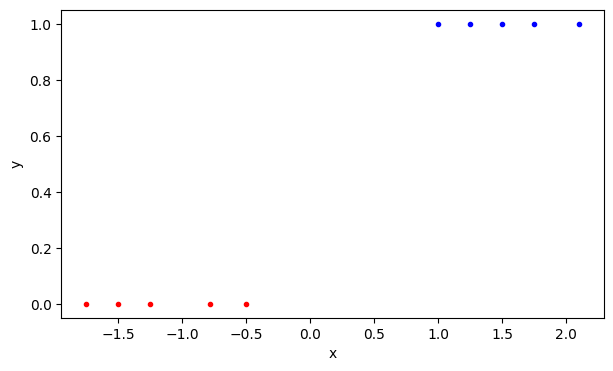

In [29]:
#Ploteamos
x = ds.x
y = ds.y

plt.figure(figsize=(7, 4))

plt.plot(x[y==0],y[y==0],'r.')  #Los puntos de clase 0 rojos
plt.plot(x[y==1],y[y==1],'b.')  #Los puntos de clase 1 azules

plt.xlabel("x")
plt.ylabel("y")

plt.show()

¿Qué pasa si utilizamos una regresión lineal, para luego separar las clases en función de su resultado?

In [30]:
#Creo un regresor lineal
modelo_lineal_simple = LinearRegression()

#Doy el formato adecuado a las variables dependiente e independiente
x_=ds.x.values.reshape(-1, 1)
y_=ds.y.values.reshape(-1, 1)

#Ajusto el modelo
modelo_lineal_simple.fit(x_,y_)

#Parámetros estimados
B1_e=round(modelo_lineal_simple.coef_[0][0],2)
B0_e=round(modelo_lineal_simple.intercept_[0],2)

#Muestro el modelo
print(f" El modelo lineal simple ajustado es : y = {B1_e} * X  + {B0_e}")

 El modelo lineal simple ajustado es : y = 0.34 * X  + 0.44


Veamos en un gráfico el modelo ajustado

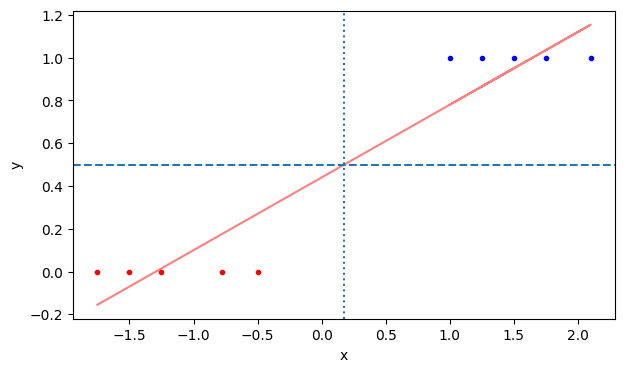

In [31]:
#Calculo los valores que estima mi modelo lineal simple
corte=0.5 #umbral de decision

y_e=B1_e *x_ + B0_e
x_limite=(corte-B0_e)/B1_e #punto de corte en el eje x donde el modelo cruza el umbral de decision

#Grafico las observaciones reales + las estimadas
plt.figure(figsize=(7, 4))
plt.xlabel("x")
plt.ylabel("y")

plt.plot(x[y==0],y[y==0],'r.')
plt.plot(x[y==1],y[y==1],'b.')

plt.plot(x_,y_e,label='data', color='red',alpha=0.5)
plt.axvline(x=x_limite,linestyle="dotted")
plt.axhline(y=corte,linestyle="dashed")
plt.show()

Para poder clasificar las observciones necesitamos adoptar un criterio que me permita dividir en 2 clases. <br>

Proponemos el siguiente criterio: si el valor de y estimado por el modelo es mayor a 0,5 entonces la observación pertenecerá a la clase 0 si no a la clase 1.

Parece funcionar bien? Veamos un caso mas complejo

#### Problema 2: Clasificación compleja en 1 dimensión

In [32]:
ds2=pd.DataFrame()
ds2['x']=[1,0.5,3.15,7.1,3.75,0.1,-0.78,-1.25,-1.5,-1.75,0.1] #Valores de X
ds2['y']=[1,1,1,1,1,0,0,0,0,0,1] #Target

ds2.head()

,x,y
0,1.00,1
1,0.50,1
2,3.15,1
3,7.10,1
4,3.75,1


Veamos gráficamente el dataset

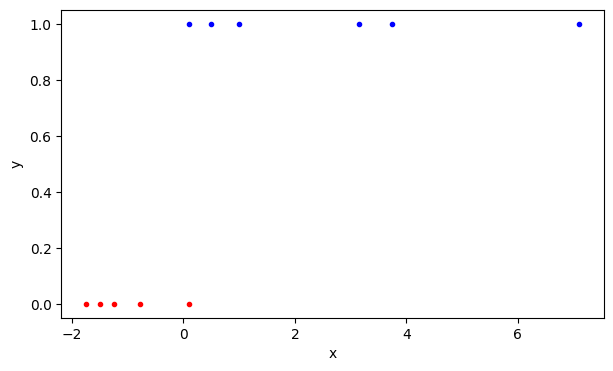

In [33]:
corte=0.5

x2 = ds2.x.values.reshape(11,1)
y2 = ds2.y.values.reshape(11,1)

plt.figure(figsize=(7, 4))
plt.xlabel("x")
plt.ylabel("y")
plt.plot(x2[y2==0],y2[y2==0],'r.')
plt.plot(x2[y2==1],y2[y2==1],'b.')
plt.show()

Ajustemos un modelo y veamos la recta ajustada en un gráfico

In [34]:
#Creo un regresor lineal
modelo_lineal_simple = LinearRegression()

#Doy el formato adecuado a las variables dependiente e independiente
x2_=x2.reshape(-1, 1)
y2_=y2.reshape(-1, 1)

#Ajusto el modelo
modelo_lineal_simple.fit(x2_,y2_)

#Parámetros estimados
B1_e=round(modelo_lineal_simple.coef_[0][0],2)
B0_e=round(modelo_lineal_simple.intercept_[0],2)

#Muestro el modelo
print(f" El modelo lineal simple ajustado es : y = {B1_e} * X  + {B0_e}")

 El modelo lineal simple ajustado es : y = 0.14 * X  + 0.42


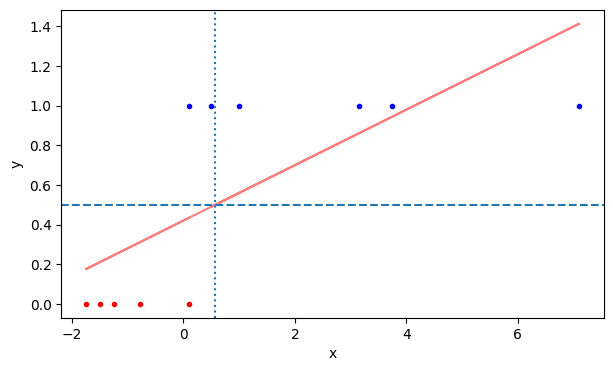

In [35]:
#Calculo los valores que estima mi modelo lineal simple
corte=0.5 #umbral de decision

y2_e=B1_e *x2_ + B0_e
x2_limite=(corte-B0_e)/B1_e #punto de corte en el eje x donde el modelo cruza el umbral de decision

#Grafico las observaciones reales + las estimadas
plt.figure(figsize=(7, 4))
plt.xlabel("x")
plt.ylabel("y")

plt.plot(x2[y2==0],y2[y2==0],'r.')
plt.plot(x2[y2==1],y2[y2==1],'b.')
plt.plot(x2_,y2_e,label='data', color='red',alpha=0.5)
plt.axvline(x=x2_limite,linestyle="dotted")
plt.axhline(y=corte,linestyle="dashed")

plt.show()

¿Qué criterio elegirían para separar las clases?


El modelo de regresión lineal puede funcionar bien para la regresión, **pero falla para la clasificación**. En el caso de dos clases, puede etiquetar una de las clases con 0 y la otra con 1 y usar la regresión lineal. Técnicamente funciona pero hay algunos problemas con este enfoque.<br>

* Un modelo lineal **no genera probabilidades**, sino que trata las clases como números (0 y 1) y ajusta el mejor hiperplano (para una sola variables, es una recta) que minimiza las distancias entre los puntos y el hiperplano. Entonces simplemente interpola entre los puntos y no podemos interpretarlo como probabilidades. La regresión lineal no entiende de probabilidades, solo “aproxima números”.<br>

* Un modelo lineal también extrapola y le da valores por debajo de cero y por encima de uno, lo que los hace difíciles (o directamente imposibles) para interpretarlos como probabilidades. Obviamente, eso no tiene sentido, porque una probabilidad debe estar en el rango [0,1]. Esta es una buena señal de que podría haber un enfoque más inteligente para la clasificación.<br>

* Dado que el resultado predicho no es una probabilidad, sino una interpolación lineal entre puntos, no existe un umbral significativo en el que pueda distinguir una clase de otra.<br>

* Además, la regresión lineal tiene problemas con la clasificación de múltiples clases. Si se la aplica a clasificación, se tendría que etiquetar las clases como 0, 1, 2, y así sucesivamente. Sin embargo, esto impone un orden numérico a las clases que podría no tener sentido, creando una estructura artificial entre los features y las predicciones de clase. Por ejemplo, una variable con un peso positivo aumentaría incorrectamente la probabilidad de predecir clases con números más altos, incluso si esas clases no están lógicamente más cerca entre sí, ya que la relación entre las clases no tiene por qué ser numérica o secuencial. Un modelo lineal no captura correctamente la naturaleza de las clases cuando no hay un orden implícito entre ellas.

Para resolver estos problemas resulta más adecuado utilizar la regresión logística.

Recomendamos leer el capítulo de regresión logística de [Interpretable Machine Learning: A Guide for Making Black Box Models Explainable de Molnar Cristoph](https://christophm.github.io/interpretable-ml-book/logistic.html) para mayor detalle

### Regresión Logística

En lugar de ajustar una línea recta o un hiperplano, el modelo de regresión logística utiliza la función logística para comprimir la salida de una ecuación lineal entre 0 y 1. La función logística se define como:

\begin{equation}
s(z) = \frac{1}{1 + e^{-z}}
\end{equation}

Esta es conocida también como Función Sigmoidea. ¿Qué forma tiene?

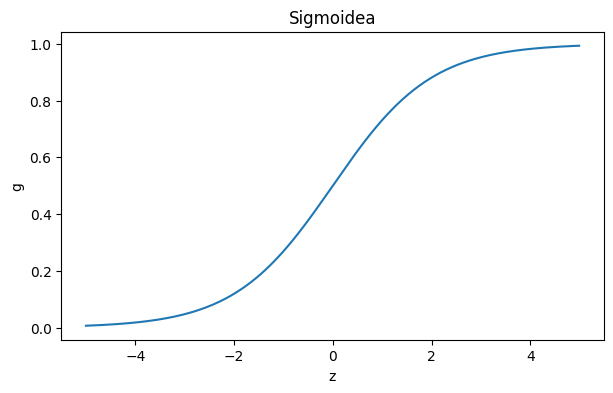

In [36]:
s = np.arange( -5, 5, 0.01)
g = 1/(1 + np.exp(-s))
plt.figure(figsize=(7, 4))
plt.plot(s,g)
plt.xlabel("z")
plt.ylabel("g")
plt.title("Sigmoidea")
plt.show()

In [37]:
s.shape

(1000,)

In [38]:
g.shape

(1000,)

#### ¿Cuáles son los parámetros del modelo?

$$s_\theta(x) = g(\beta^T x) =  \frac{1}{1+ e^{(-\beta^T x)}}$$

Donde:

* $x$ = vector de características (variables de entrada).

* $\beta$ = vector de parámetros (los “pesos” que aprende el modelo).

* $\beta^T x$ = combinación lineal de las variables.

* $g(\cdot)$ = la función sigmoide, que “aprieta” cualquier valor real dentro del rango (0,1).

👉 La salida de la función sigmoidea es continua entre 0 y 1, pudiéndose interpretar como probabilidad de pertenencia a la clase 1

Seguimos necesitando definir un umbral, continuemos considerando 0,5
  * Si $s_\theta(x) < 0.5$  entonces $x$ pertencerá a la clase 0
  * Si $s_\theta(x) \ge 0.5$  entonces $x$ pertencerá a la clase 1

👉 Este paso convierte una probabilidad en una decisión de clase.

<br>

Elegir como umbral 0.5 nos da una interpretación simple de  $\beta^Tx$:
$$ s_\theta(x) = 0.5 \\ \Rightarrow \beta^Tx = 0$$
👉 Este es el frontera de decisión: los puntos donde la probabilidad predicha es exactamente 0.5. Es la ecuación de un hiperplano!


Ejemplo con dos variables ($x_1, x_2$):

$\beta_0 +\beta_1 x_1 + \beta_2 x_2 =0 $

<br>

Despejando $x_2$, se puede transformar en:

$- \beta_2 x_2 = \beta_0 +\beta_1 x_1 $

$ x_2 =   - \frac{\beta_1}{\beta_2} x_1 - \frac{\beta_0}{\beta_2}$

* La pendiente es $-\beta_1 / \beta_2$.

* El intercepto es $-\beta_0 / \beta_2$.

Esa recta divide el espacio en dos regiones:

* De un lado: $s_\theta(x) < 0.5$ (clase 0).

* Del otro lado: $s_\theta(x) \ge 0.5$ (clase 1).

#### Interpretación de los coeficientes

La interpretación de los pesos en la regresión logística difiere de la interpretación de los pesos en la regresión lineal, ya que el resultado en la regresión logística es un valor entre 0 y 1.

* En regresión lineal, los coeficientes ($\beta$) indican cuánto cambia la variable de salida en promedio cuando una variable de entrada aumenta en 1 unidad.
* En cambio, en regresión logística, la salida es una probabilidad entre 0 y 1, y ahí los pesos no se interpretan linealmente.

##### Log-ods: el puente intermedio

Para poder interpretar los coeficientes, se transforma la probabilidad en odds y luego en log-odds:

* Odds = $\dfrac{P}{1-P}$ → “probabilidad de que ocurra / probabilidad de que no ocurra”.

* Log-odds = $\ln\left(\dfrac{P}{1-P}\right)$.

<br>

La regresión logística predice linealmente los log-odds. Luego de un despeje obtenemos la siguiente funcion:

$\text{log-odds} = \ln\left(\frac{P}{1-P}\right) = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n$


* Si una variable $X_j$ aumenta en 1 unidad, el log-odds aumenta en $\beta_j$.

* En términos de odds, esto significa que los odds se multiplican por $e^{\beta_j}$.

La mayoría de las personas interpretan el cociente de odds porque pensar en los log-odds de algo se sabe que es difícil de entender. Interpretar el cociente de odds ya requiere algo de acostumbrarse.

Ejemplo: si $\beta = 0.7$, entonces $e^{0.7} \approx 2$. Esto significa que los odds se duplican al aumentar $X$ en una unidad (y luego esos odds se transforman a probabilidad).

Usualmente no se trabaja con los odds y solo se interpretan los pesos como cocientes de odds, porque para calcular los odds realmente necesitaríamos asignar un valor a cada característica, lo que solo tiene sentido si se desea observar una instancia específica del conjunto de datos.

Las interpretaciones para el modelo de regresión logística con diferentes tipos de características:

* Característica numérica: Si aumentas el valor de una variable en una unidad, los odds estimados cambian por un factor de $exp(𝛽)$.

* Característica categórica binaria: Uno de los dos valores de la característica es la categoría de referencia (normalmente codificada como 0). Cambiar de la categoría de referencia a la otra cambia los odds estimados por un factor de $exp(𝛽)$

* Característica categórica con más de dos categorías: Se puede usar one-hot encoding, donde cada categoría tiene su propia columna. Para una característica con L categorías, se necesitan L-1 columnas. La L-ésima categoría es la de referencia. La interpretación de cada categoría es similar a la de las características binarias.

* Intercepto: Cuando todas las características numéricas son cero y las categóricas están en la categoría de referencia, los odds estimados son 1. La interpretación del peso del intercepto generalmente no es relevante.

**Importante: no es lineal en probabilidades**
Aunque el modelo es lineal en log-odds, **en términos de probabilidad no es lineal**. Un aumento de una unidad en $X$ no suma siempre lo mismo a la probabilidad, sino que cambia la probabilidad de forma no lineal. Esto se puede ver por ejemplo en la curva logística en forma de “S”, donde los cambios son más fuertes en el medio (cerca de 0.5) y casi nulos en los extremos (cerca de 0 o 1).

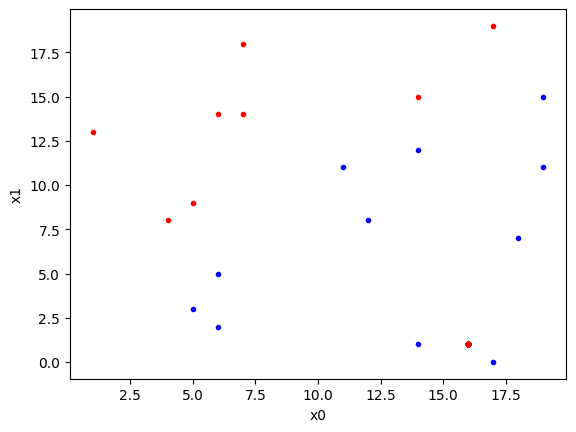

In [39]:
#Genero un dataset sintético
X = np.random.randint(20,size=(20,2)) # Generar un dataset sintético con 20 puntos y 2 características
beta = np.array([[-0.1],[0.1]]) # coeficientes (pesos) x0 y x1 para la regresión logística
# beta = np.array([[-1],[1]])
Y = np.round( 1/(1+np.exp(np.dot(-X, beta)))) # Calculamos la probabilidad de la clase 1 y la redondeamos a 0 o 1

# Separo los índices de los puntos donde Y = 0 y Y = 1
ind0 = np.where(Y==0)
ind1 = np.where(Y==1)

# Grafico los puntos de clase 0 (en azul) y clase 1 (en rojo)
plt.plot(X[ind0,0],X[ind0,1],'b.')
plt.plot(X[ind1,0],X[ind1,1],'r.')
plt.xlabel("x0")
plt.ylabel("x1")
plt.show()

In [40]:
X

array([[16,  1],
       [ 6,  5],
       [14, 15],
       [18,  7],
       [ 6,  2],
       [12,  8],
       [19, 11],
       [ 4,  8],
       [ 6, 14],
       [14, 12],
       [17, 19],
       [ 1, 13],
       [ 5,  3],
       [17,  0],
       [11, 11],
       [14,  1],
       [ 5,  9],
       [ 7, 18],
       [19, 15],
       [ 7, 14]])

Generemos un clasificador de tipo regresión logística

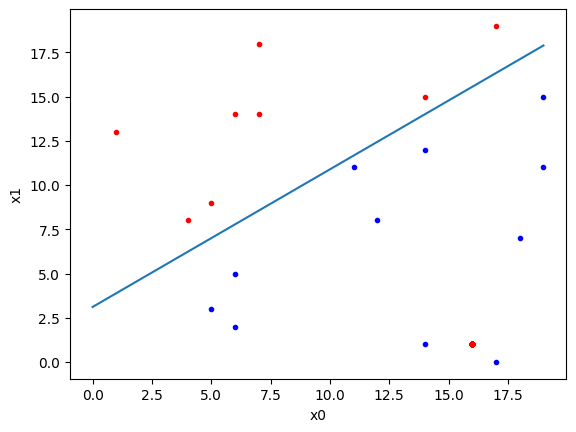

In [41]:
#Creo el clasificador
clf = LogisticRegression()
clf.fit(X, Y)

#Obtengo coeficientes para el modelo b0 + b1X + b2Y=0
beta_0 = clf.intercept_
beta_1 = clf.coef_[0,0]
beta_2 = clf.coef_[0,1]

#Graficamos
x1 = np.arange(0,20,1) #Genero valores para x
x2 = - beta_1/beta_2*x1 - beta_0/beta_2 #Ecuación de la recta que separa las dos clases (0 y 1)
plt.plot(x1,x2)

ind0 = np.where(Y==0)
ind1 = np.where(Y==1)
plt.plot(X[ind0,0],X[ind0,1],'b.')
plt.plot(X[ind1,0],X[ind1,1],'r.')
plt.xlabel("x0")
plt.ylabel("x1")
plt.show()

Esta línea de decisión es fundamental para entender cómo el modelo de regresión logística clasifica los puntos. Si un punto está por encima de esta línea, será clasificado en una clase (por ejemplo, 1), y si está por debajo, será clasificado en otra clase (por ejemplo, 0). La línea en sí misma representa el punto de indiferencia entre las dos clases, donde el modelo asigna una probabilidad de 50% para cada clase.

Volviendo a nuestro ejemplo complejo de 1 dimensión

In [42]:
x2 = ds2.x.values.reshape(11,1)
y2 = ds2.y.values.reshape(11,1)

modelo_rl = LogisticRegression()
modelo_rl.fit(x2, y2)

y_pred_modelo_rl = modelo_rl.predict(x2)

# ordeno el input a predecir unicamente con fines graficos posteriores
sorted_x2 = np.sort(x2.ravel()).reshape(x2.shape)
#Calculo los valores que estima mi modelo lineal simple
y_pred_proba_modelo_rl = modelo_rl.predict_proba(sorted_x2)[:, 1]

In [43]:
modelo_rl.predict(sorted_x2)

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1])

In [44]:
modelo_rl.predict_proba(sorted_x2)

array([[9.08975349e-01, 9.10246514e-02],
       [8.79346964e-01, 1.20653036e-01],
       [8.41753540e-01, 1.58246460e-01],
       [7.46355960e-01, 2.53644040e-01],
       [4.92682440e-01, 5.07317560e-01],
       [4.92682440e-01, 5.07317560e-01],
       [3.69781205e-01, 6.30218795e-01],
       [2.38120856e-01, 7.61879144e-01],
       [2.04045462e-02, 9.79595454e-01],
       [9.68728273e-03, 9.90312717e-01],
       [1.43758949e-04, 9.99856241e-01]])

In [45]:
y_pred_proba_modelo_rl

array([0.09102465, 0.12065304, 0.15824646, 0.25364404, 0.50731756,
       0.50731756, 0.63021879, 0.76187914, 0.97959545, 0.99031272,
       0.99985624])

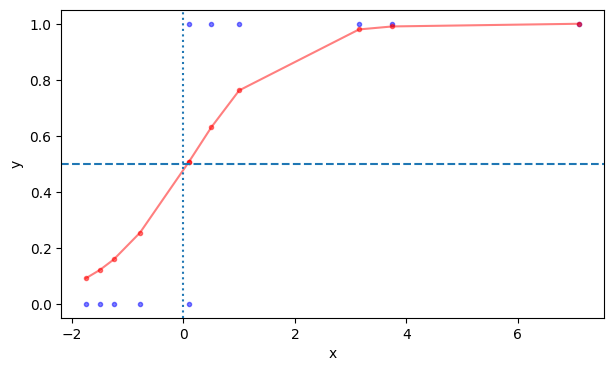

In [46]:
#puntos de corte
corte=0.5
x2_limite=0

#Grafico las observaciones reales + las estimadas
plt.figure(figsize=(7, 4))
plt.xlabel("x")
plt.ylabel("y")

plt.scatter(x2,y2,label='data', color='blue',alpha=0.5,marker='.') #datos a predecir
plt.plot(sorted_x2,y_pred_proba_modelo_rl,label='data', color='red',alpha=0.5,marker='.') #predicciones
plt.axvline(x=x2_limite,linestyle="dotted")
plt.axhline(y=corte,linestyle="dashed")

plt.show()